In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [2]:
CSV_PATH = "../data/data_master.csv"
PLASTIC_GLOSSY_BATCHES = [
    "Batch 1 - Cycles AGX",
    "Batch 2 - Cycles AGX Punchy",
    "Batch 3 - Cycles Filmic",
    "Batch 4 - Cycles Filmic High Contrast",
]

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

np.random.seed(42)
tf.random.set_seed(42)

def resolve_existing_path(row: pd.Series) -> str | None:
    candidates = []
    dataset_source = str(row.get("dataset_source", "")).strip()
    image_relpath = str(row.get("image_relpath", "")).strip()

    for raw in (row.get("resolved_image_relpath"), row.get("image_relpath")):
        if pd.isna(raw):
            continue
        raw = str(raw).strip()
        if not raw or raw.lower() == "nan":
            continue
        candidates.extend([raw, os.path.join("..", raw), os.path.join("..", "data", raw)])

    if dataset_source == "render-lighting":
        candidates.append(os.path.join("..", "data", "render-lighting", image_relpath))
    elif dataset_source == "inverse_rendering_dataset":
        candidates.append(os.path.join("..", "data", "inverse_rendering_dataset", image_relpath))
        candidates.append(os.path.join("..", "data", "inverse_rendering_dataset", "images", image_relpath))

    seen = set()
    for path in candidates:
        norm = os.path.normpath(path)
        if norm in seen:
            continue
        seen.add(norm)
        if os.path.exists(norm):
            return norm
    return None

def include_training_row(row: pd.Series) -> bool:
    dataset_source = str(row.get("dataset_source", "")).strip()
    if dataset_source == "render-lighting":
        return str(row.get("batch_folder", "")).strip() in PLASTIC_GLOSSY_BATCHES
    return dataset_source == "inverse_rendering_dataset"

def classify_light_type(row: pd.Series) -> str:
    light_folder = str(row.get("light_folder", "")).strip()
    num_lights = int(row.get("num_active_lights", 0) or 0)

    if num_lights == 2:
        l0 = str(row.get("light0_type", "")).upper()
        l1 = str(row.get("light1_type", "")).upper()
        if l0 and l1 and l0 != "NAN" and l1 != "NAN":
            return f"DOUBLE_{l0}_{l1}"
        return "DOUBLE_LIGHT"

    if light_folder.lower() == "single_light":
        return "SPOT LIGHT"

    if "HDRI" in light_folder.upper():
        return "HDRI"

    return light_folder.upper() if light_folder else "UNKNOWN"

def _decode_resize(path: tf.Tensor, label: tf.Tensor):
    image = tf.io.read_file(path)
    image = tf.io.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE, method="bilinear")
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def make_image_dataset(paths, labels, training=False):
    paths = np.asarray(paths, dtype=str)
    labels = np.asarray(labels, dtype=np.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(paths), reshuffle_each_iteration=True)

    ds = ds.map(_decode_resize, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds


In [3]:
df = pd.read_csv(CSV_PATH, low_memory=False)

train_mask = df.apply(include_training_row, axis=1)
count_filtered = df[
    train_mask
    & (df["num_active_lights"].astype(int).isin([1, 2, 3]))
] .copy()

print(f"Total filtered rows: {len(count_filtered)}")
print(f"\nDataset distribution:")
print(count_filtered["dataset_source"].value_counts())
print(f"\nLight count distribution:")
print(count_filtered["num_active_lights"].value_counts().sort_index())
print(f"\nLight types in data:")
print(count_filtered["light_folder"].value_counts())

Total filtered rows: 23529

Dataset distribution:
dataset_source
render-lighting              21216
inverse_rendering_dataset     2313
Name: count, dtype: int64

Light count distribution:
num_active_lights
1    17385
2      840
3     5304
Name: count, dtype: int64

Light types in data:
light_folder
Point Light     5304
Spot Light      5304
Area Light      5304
Tri Lighting    5304
single_light    1473
double_light     840
Name: count, dtype: int64


In [4]:
count_filtered["image_path"] = count_filtered.apply(resolve_existing_path, axis=1)
count_filtered = count_filtered[count_filtered["image_path"].notna()].reset_index(drop=True)

print(f"Images found: {len(count_filtered)}")

# convert labels to 0-indexed classes (1->0, 2->1, 3->2)
y_count_raw = count_filtered["num_active_lights"].astype(int).values
y_count = y_count_raw - 1
num_count_classes = 3  # always expect 1, 2, 3 lights
count_paths = count_filtered["image_path"].values

print(f"y_count shape: {y_count.shape}")
print(f"Number of classes: {num_count_classes}")
print(f"Unique classes in data: {np.unique(y_count)}")
print(f"Class distribution: {np.bincount(y_count)}")

Images found: 23529
y_count shape: (23529,)
Number of classes: 3
Unique classes in data: [0 1 2]
Class distribution: [17385   840  5304]


In [5]:
count_paths_train, count_paths_test, y_count_train, y_count_test = train_test_split(
    count_paths, y_count, test_size=0.2, random_state=42, stratify=y_count
)
count_paths_train, count_paths_val, y_count_train, y_count_val = train_test_split(
    count_paths_train, y_count_train, test_size=0.2, random_state=42, stratify=y_count_train
)

ds_count_train = make_image_dataset(count_paths_train, y_count_train, training=True)
ds_count_val = make_image_dataset(count_paths_val, y_count_val, training=False)
ds_count_test = make_image_dataset(count_paths_test, y_count_test, training=False)

print("Train/Val/Test split:")
print(f"  Train: {len(count_paths_train)} samples")
print(f"  Val: {len(count_paths_val)} samples")
print(f"  Test: {len(count_paths_test)} samples")

Train/Val/Test split:
  Train: 15058 samples
  Val: 3765 samples
  Test: 4706 samples


W0000 00:00:1773410471.527857    4311 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [6]:
count_model = keras.Sequential([
    keras.Input(shape=(*IMG_SIZE, 3)),
    layers.Conv2D(32, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.Conv2D(256, 3, activation="relu", padding="same"),
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_count_classes, activation="softmax", name="light_count")
])

count_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

count_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ light_count (Dense)             │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 429,763 (1.64 MB)

 Trainable params: 429,763 (1.64 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
count_callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6)
]

count_history = count_model.fit(
    ds_count_train,
    validation_data=ds_count_val,
    epochs=25,
    callbacks=count_callbacks,
    verbose=1
)

Epoch 1/25
471/471 ━━━━━━━━━━━━━━━━━━━━ 198s 416ms/step - accuracy: 0.7600 - loss: 0.5312 - val_accuracy: 0.7976 - val_loss: 0.4195 - learning_rate: 0.0010
Epoch 2/25
471/471 ━━━━━━━━━━━━━━━━━━━━ 194s 412ms/step - accuracy: 0.8485 - loss: 0.3261 - val_accuracy: 0.8810 - val_loss: 0.2523 - learning_rate: 0.0010
Epoch 3/25
471/471 ━━━━━━━━━━━━━━━━━━━━ 195s 413ms/step - accuracy: 0.8981 - loss: 0.2287 - val_accuracy: 0.9086 - val_loss: 0.1927 - learning_rate: 0.0010
Epoch 4/25
471/471 ━━━━━━━━━━━━━━━━━━━━ 195s 414ms/step - accuracy: 0.9303 - loss: 0.1608 - val_accuracy: 0.9365 - val_loss: 0.1383 - learning_rate: 0.0010
Epoch 5/25
471/471 ━━━━━━━━━━━━━━━━━━━━ 194s 412ms/step - accuracy: 0.9398 - loss: 0.1312 - val_accuracy: 0.9533 - val_loss: 0.1084 - learning_rate: 0.0010
Epoch 6/25
471/471 ━━━━━━━━━━━━━━━━━━━━ 195s 413ms/step - accuracy: 0.9493 - loss: 0.1048 - val_accuracy: 0.9599 - val_loss: 0.0780 - learning_rate: 0.0010
Epoch 7/25
471/471 ━━━━━━━━━━━━━━━━━━━━ 195s 413ms/step - accura

Test Loss: 0.0427
Test Accuracy: 0.9781

Classification Report:
              precision    recall  f1-score   support

     1 Light       0.98      0.99      0.99      3477
    2 Lights       0.72      0.63      0.67       168
    3 Lights       1.00      1.00      1.00      1061

    accuracy                           0.98      4706
   macro avg       0.90      0.87      0.89      4706
weighted avg       0.98      0.98      0.98      4706



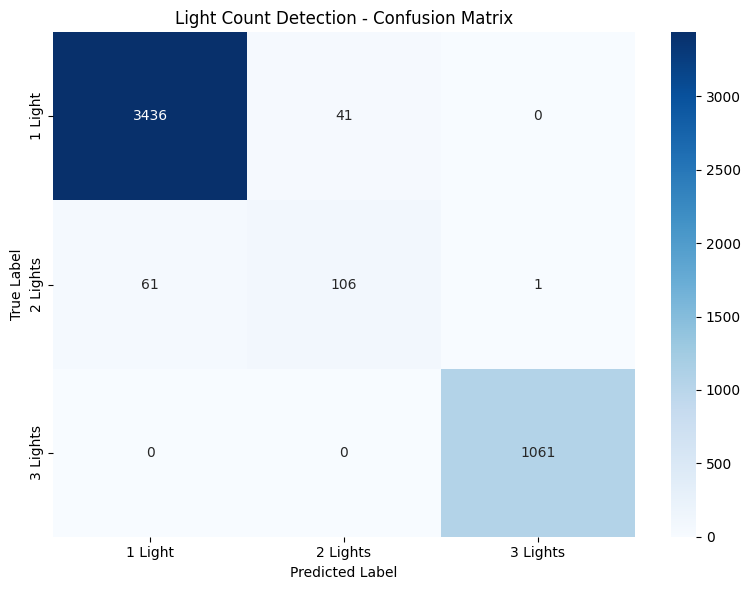

In [8]:
count_test_loss, count_test_acc = count_model.evaluate(ds_count_test, verbose=0)
print(f"Test Loss: {count_test_loss:.4f}")
print(f"Test Accuracy: {count_test_acc:.4f}")
print()

y_count_pred = count_model.predict(ds_count_test, verbose=0)
y_count_pred_classes = np.argmax(y_count_pred, axis=1)

# convert back to actual light counts (1, 2, 3) for display
count_labels = sorted(np.unique(y_count_raw).tolist())
class_names = [f"{count} Light" if count == 1 else f"{count} Lights" for count in count_labels]

print("Classification Report:")
print(classification_report(y_count_test, y_count_pred_classes, target_names=class_names))

# confusion matrix
cm = confusion_matrix(y_count_test, y_count_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Light Count Detection - Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

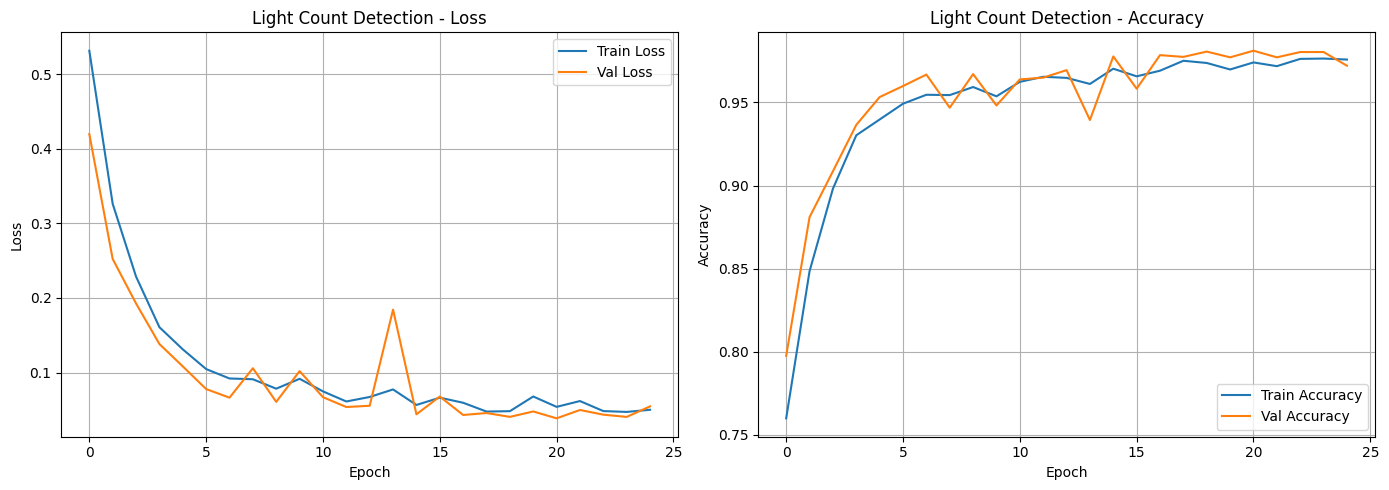

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(count_history.history["loss"], label="Train Loss")
ax1.plot(count_history.history["val_loss"], label="Val Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Light Count Detection - Loss")
ax1.legend()
ax1.grid(True)

ax2.plot(count_history.history["accuracy"], label="Train Accuracy")
ax2.plot(count_history.history["val_accuracy"], label="Val Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Light Count Detection - Accuracy")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [10]:
# save model
count_model.save("light_count_detector.keras")
print("Light count detection model saved!")

Light count detection model saved!


In [11]:
type_filtered = df[train_mask].copy()

print(f"Total filtered rows: {len(type_filtered)}")
print(f"\nDataset distribution:")
print(type_filtered["dataset_source"].value_counts())
print(f"\nLight type distribution:")
print(type_filtered["light_folder"].value_counts())

type_filtered["light_type"] = type_filtered.apply(classify_light_type, axis=1)

print(f"\nGrouped light type distribution:")
print(type_filtered["light_type"].value_counts())

Total filtered rows: 34137

Dataset distribution:
dataset_source
render-lighting              31824
inverse_rendering_dataset     2313
Name: count, dtype: int64

Light type distribution:
light_folder
Point Light        5304
Spot Light         5304
Area Light         5304
Tri Lighting       5304
HDRI (Sunlight)    5304
HDRI (Overcast)    5304
single_light       1473
double_light        840
Name: count, dtype: int64

Grouped light type distribution:
light_type
HDRI                10608
SPOT LIGHT           6777
POINT LIGHT          5304
AREA LIGHT           5304
TRI LIGHTING         5304
DOUBLE_SPOT_SPOT      840
Name: count, dtype: int64


In [12]:
type_filtered["image_path"] = type_filtered.apply(resolve_existing_path, axis=1)
type_filtered = type_filtered[type_filtered["image_path"].notna()].reset_index(drop=True)

print(f"Images found: {len(type_filtered)}")

# create label encoding
light_types = sorted(type_filtered["light_type"].unique())
light_type_to_idx = {lt: idx for idx, lt in enumerate(light_types)}
idx_to_light_type = {idx: lt for lt, idx in light_type_to_idx.items()}

y_type = type_filtered["light_type"].map(light_type_to_idx).values
num_type_classes = len(light_types)
type_paths = type_filtered["image_path"].values

print(f"y_type shape: {y_type.shape}")
print(f"Number of classes: {num_type_classes}")
print(f"\nClass mapping: {light_type_to_idx}")
print(f"Class distribution: {np.bincount(y_type)}")

Images found: 23529
y_type shape: (23529,)
Number of classes: 5

Class mapping: {'AREA LIGHT': 0, 'DOUBLE_SPOT_SPOT': 1, 'POINT LIGHT': 2, 'SPOT LIGHT': 3, 'TRI LIGHTING': 4}
Class distribution: [5304  840 5304 6777 5304]


In [13]:
type_paths_train, type_paths_test, y_type_train, y_type_test = train_test_split(
    type_paths, y_type, test_size=0.2, random_state=42, stratify=y_type
)
type_paths_train, type_paths_val, y_type_train, y_type_val = train_test_split(
    type_paths_train, y_type_train, test_size=0.2, random_state=42, stratify=y_type_train
)

ds_type_train = make_image_dataset(type_paths_train, y_type_train, training=True)
ds_type_val = make_image_dataset(type_paths_val, y_type_val, training=False)
ds_type_test = make_image_dataset(type_paths_test, y_type_test, training=False)

print("Train/Val/Test split:")
print(f"  Train: {len(type_paths_train)} samples")
print(f"  Val: {len(type_paths_val)} samples")
print(f"  Test: {len(type_paths_test)} samples")

Train/Val/Test split:
  Train: 15058 samples
  Val: 3765 samples
  Test: 4706 samples


In [14]:
type_model = keras.Sequential([
    keras.Input(shape=(*IMG_SIZE, 3)),
    layers.Conv2D(32, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.Conv2D(256, 3, activation="relu", padding="same"),
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_type_classes, activation="softmax", name="light_type")
])

type_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

type_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ light_type (Dense)              │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 487,749 (1.86 MB)

 Trainable params: 487,749 (1.86 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
type_callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6)
]

type_history = type_model.fit(
    ds_type_train,
    validation_data=ds_type_val,
    epochs=25,
    callbacks=type_callbacks,
    verbose=1
)

Epoch 1/25
471/471 ━━━━━━━━━━━━━━━━━━━━ 172s 364ms/step - accuracy: 0.5455 - loss: 0.9677 - val_accuracy: 0.7551 - val_loss: 0.5385 - learning_rate: 0.0010
Epoch 2/25
471/471 ━━━━━━━━━━━━━━━━━━━━ 170s 361ms/step - accuracy: 0.7646 - loss: 0.5227 - val_accuracy: 0.8457 - val_loss: 0.3748 - learning_rate: 0.0010
Epoch 3/25
471/471 ━━━━━━━━━━━━━━━━━━━━ 170s 361ms/step - accuracy: 0.8420 - loss: 0.3537 - val_accuracy: 0.8733 - val_loss: 0.2964 - learning_rate: 0.0010
Epoch 4/25
471/471 ━━━━━━━━━━━━━━━━━━━━ 170s 360ms/step - accuracy: 0.8516 - loss: 0.3342 - val_accuracy: 0.8691 - val_loss: 0.2470 - learning_rate: 0.0010
Epoch 5/25
471/471 ━━━━━━━━━━━━━━━━━━━━ 169s 360ms/step - accuracy: 0.8808 - loss: 0.2644 - val_accuracy: 0.8738 - val_loss: 0.2701 - learning_rate: 0.0010
Epoch 6/25
471/471 ━━━━━━━━━━━━━━━━━━━━ 168s 357ms/step - accuracy: 0.8935 - loss: 0.2297 - val_accuracy: 0.9272 - val_loss: 0.1639 - learning_rate: 0.0010
Epoch 7/25
471/471 ━━━━━━━━━━━━━━━━━━━━ 168s 356ms/step - accura

Test Loss: 0.0449
Test Accuracy: 0.9756

Classification Report:
                  precision    recall  f1-score   support

      AREA LIGHT       1.00      1.00      1.00      1061
DOUBLE_SPOT_SPOT       0.76      0.63      0.69       168
     POINT LIGHT       0.99      0.99      0.99      1061
      SPOT LIGHT       0.95      0.97      0.96      1355
    TRI LIGHTING       1.00      1.00      1.00      1061

        accuracy                           0.98      4706
       macro avg       0.94      0.92      0.93      4706
    weighted avg       0.97      0.98      0.97      4706



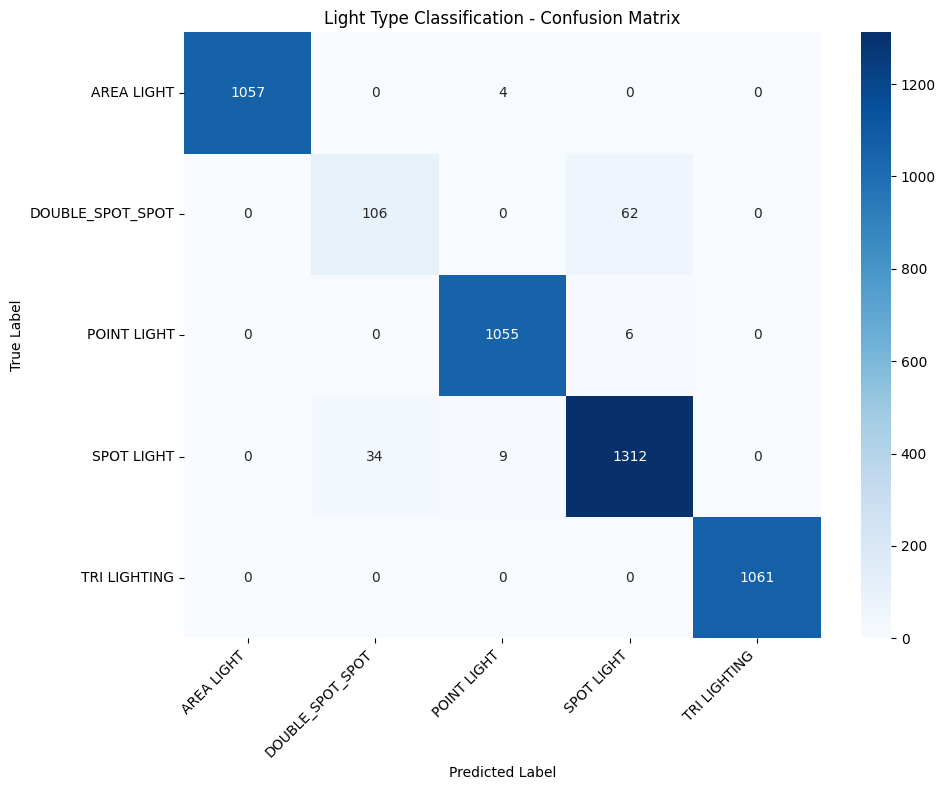

In [16]:
type_test_loss, type_test_acc = type_model.evaluate(ds_type_test, verbose=0)
print(f"Test Loss: {type_test_loss:.4f}")
print(f"Test Accuracy: {type_test_acc:.4f}")
print()

y_type_pred = type_model.predict(ds_type_test, verbose=0)
y_type_pred_classes = np.argmax(y_type_pred, axis=1)

print("Classification Report:")
print(classification_report(y_type_test, y_type_pred_classes, target_names=light_types))

# confusion matrix
cm_type = confusion_matrix(y_type_test, y_type_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_type, annot=True, fmt="d", cmap="Blues", xticklabels=light_types, yticklabels=light_types)
plt.title("Light Type Classification - Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

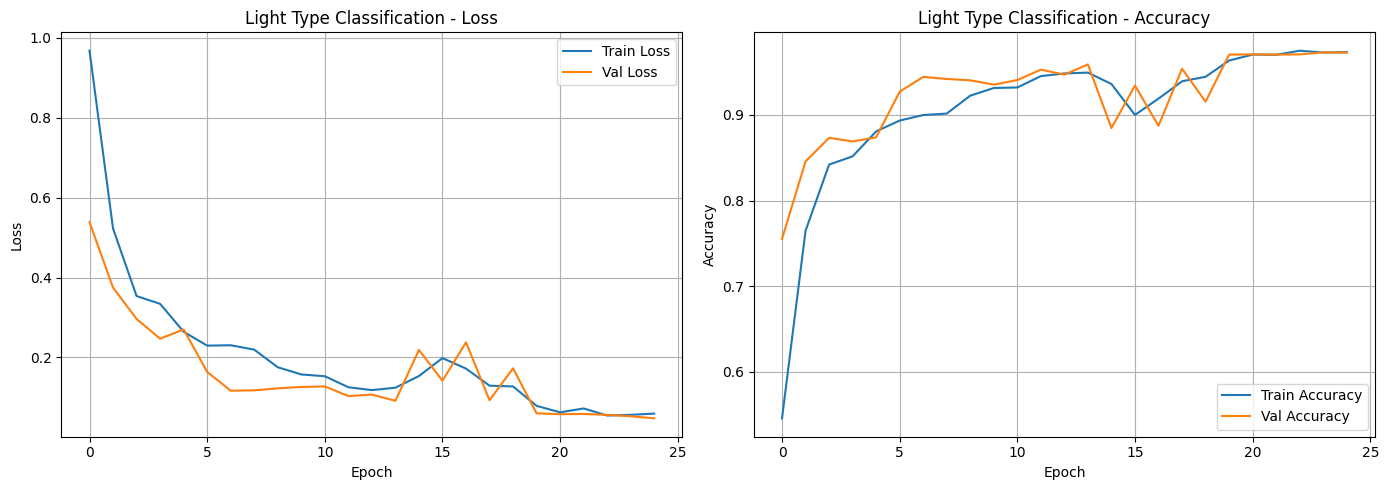

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(type_history.history["loss"], label="Train Loss")
ax1.plot(type_history.history["val_loss"], label="Val Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Light Type Classification - Loss")
ax1.legend()
ax1.grid(True)

ax2.plot(type_history.history["accuracy"], label="Train Accuracy")
ax2.plot(type_history.history["val_accuracy"], label="Val Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Light Type Classification - Accuracy")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [18]:
# save model
type_model.save("light_type_classifier.keras")
print("Light type classification model saved!")

# save label mapping
import json
with open("light_type_mapping.json", "w") as f:
    json.dump({"light_type_to_idx": light_type_to_idx, "idx_to_light_type": idx_to_light_type}, f, indent=2)
print("Label mapping saved!")

Light type classification model saved!
Label mapping saved!


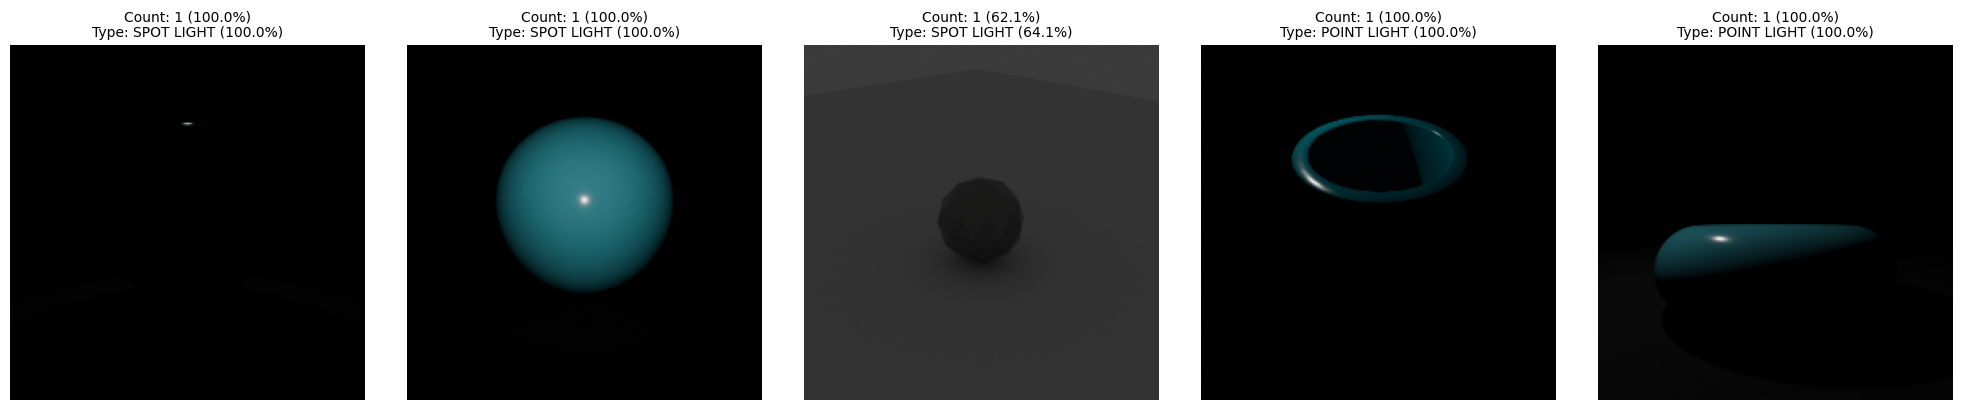

In [19]:
# test both models on random images
num_samples = min(5, len(type_paths_test))
random_indices = np.random.choice(len(type_paths_test), num_samples, replace=False)

fig, axes = plt.subplots(1, num_samples, figsize=(20, 4))
if num_samples == 1:
    axes = [axes]

for i, idx in enumerate(random_indices):
    image_path = type_paths_test[idx]
    img_tensor, _ = _decode_resize(tf.constant(image_path), tf.constant(0, dtype=tf.int32))
    img = img_tensor.numpy()
    img_batch = np.expand_dims(img, 0)

    # predict count
    count_pred = count_model.predict(img_batch, verbose=0)
    count_class = np.argmax(count_pred) + 1
    count_conf = np.max(count_pred) * 100

    # predict type
    type_pred = type_model.predict(img_batch, verbose=0)
    type_class = np.argmax(type_pred)
    type_name = idx_to_light_type[type_class]
    type_conf = np.max(type_pred) * 100

    # display
    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(
        f"Count: {count_class} ({count_conf:.1f}%)\nType: {type_name} ({type_conf:.1f}%)",
        fontsize=10,
    )

plt.tight_layout()
plt.show()